# ORCA6 Figure 4: reconstructed versus true energy


In [10]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import uproot

DATA_DIR = Path.cwd()  
ROOT_FILE = DATA_DIR / 'ORCA6_433kt-y_opendata_v0.5.root'
BIN_FILE = DATA_DIR  / 'bins_433kt-y_v0.5.json'


In [11]:
with BIN_FILE.open() as stream:
    binning = json.load(stream)

true_energy_edges = np.asarray(binning['E_true_bins'])

with uproot.open(ROOT_FILE) as root_file:
    response = root_file['binned_nu_response']
    values = response.arrays(
        ['AnaClass', 'E_true_bin_center', 'E_reco_bin_center', 'W'],
        library='np',
    )

print(f"Read {len(values['W']):,} filled response bins.")


Read 592,099 filled response bins.


In [12]:
def weighted_quantile(samples, weights, quantiles):
    """Return weighted quantiles for non-negative response weights."""
    order = np.argsort(samples)
    samples = np.asarray(samples)[order]
    weights = np.asarray(weights)[order]
    cumulative_weight = np.cumsum(weights)
    if cumulative_weight[-1] <= 0:
        return np.full(len(quantiles), np.nan)
    return np.interp(np.asarray(quantiles) * cumulative_weight[-1], cumulative_weight, samples)

def energy_quantiles_for_class(ana_class):
    lower, median, upper = [], [], []
    class_rows = values['AnaClass'] == ana_class

    for left, right in zip(true_energy_edges[:-1], true_energy_edges[1:]):
        # Bin-centre comparison avoids any ambiguity from ROOT's bin-index convention.
        in_true_energy_bin = (values['E_true_bin_center'] >= left) & (values['E_true_bin_center'] < right)
        rows = class_rows & in_true_energy_bin
        q16, q50, q84 = weighted_quantile(
            values['E_reco_bin_center'][rows], values['W'][rows], [0.16, 0.50, 0.84]
        )
        lower.append(q16)
        median.append(q50)
        upper.append(q84)

    return np.asarray(lower), np.asarray(median), np.asarray(upper)
    

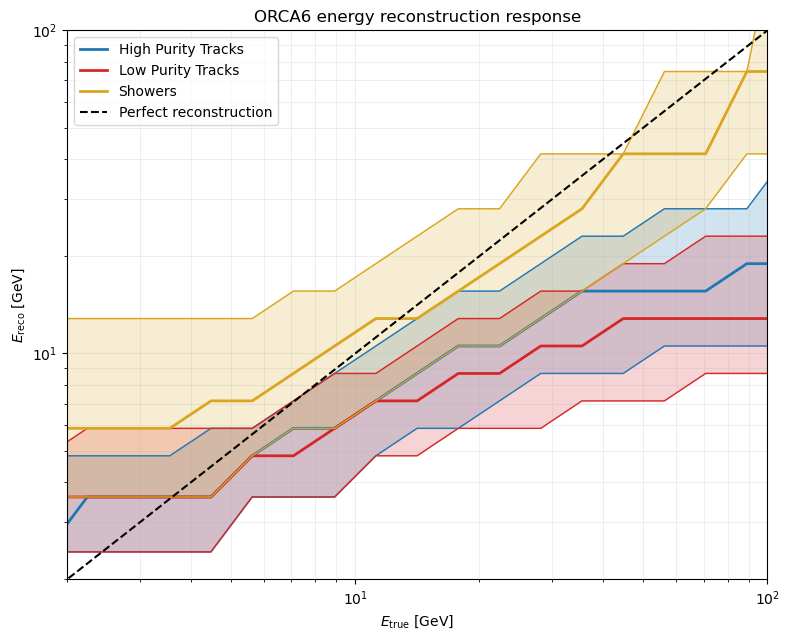

In [13]:
classes = {
    1: ('High Purity Tracks', 'tab:blue'),
    3: ('Low Purity Tracks', 'tab:red'),
    2: ('Showers', 'goldenrod'),
}
true_energy_centers = np.sqrt(true_energy_edges[:-1] * true_energy_edges[1:])

fig, ax = plt.subplots(figsize=(8, 6.5))
for ana_class, (label, color) in classes.items():
    q16, q50, q84 = energy_quantiles_for_class(ana_class)
    ax.fill_between(true_energy_centers, q16, q84, color=color, alpha=0.20)
    ax.plot(true_energy_centers, q16, color=color, lw=1)
    ax.plot(true_energy_centers, q50, color=color, lw=2, label=label)
    ax.plot(true_energy_centers, q84, color=color, lw=1)

diagonal = np.array([1.0, 1.0e4])
ax.plot(diagonal, diagonal, 'k--', lw=1.5, label='Perfect reconstruction')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2, 1.0e2)
ax.set_ylim(2, 1.0e2)
ax.set_xlabel(r'$E_{\mathrm{true}}$ [GeV]')
ax.set_ylabel(r'$E_{\mathrm{reco}}$ [GeV]')
ax.set_title('ORCA6 energy reconstruction response')
ax.grid(which='both', alpha=0.2)
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()
